In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Carga y Exploración de Datos

In [2]:
df_authors = pd.read_csv("data/entities/autores_ecuador_enriquecido.csv")
df_authors.head()

,authid,authname,surname,given-name,initials,orcid,afid,h-index,subject-areas
0,10039323700,Apolinário J.,Apolinário,J. A.,J.A.,NaN,"['101703861', '60104598']",20.0,"['Computer Science Applications', 'Astronomy a..."
1,10040479200,Almeida C.,Almeida,Carlos,C.,NaN,['60104598'],2.0,"['Computational Theory and Mathematics', 'Comp..."
2,10040712400,Carrión V.,Carrión,Víctor,V.,0009-0007-5806-5471,"['108330837', '117939271', '118823220', '13322...",11.0,"['Ecology', 'Business, Management and Accounti..."
3,10043217500,Friedman R.,Friedman,Risa,R.,NaN,['60072059'],9.0,"['Immunology', 'Medicine (all)', 'Earth and Pl..."
4,10240259200,Yandún S.,Yandún,Santiago,S.,NaN,['60072063'],2.0,['Plant Science']


In [3]:
df_authors.isnull().sum()

authid               0
authname             0
surname              0
given-name          28
initials            28
orcid            41932
afid                 0
h-index             22
subject-areas       55
dtype: int64

# Obtención de Duplicados

El criterio elegido para identificar posibles duplicados consiste en relacionar los atributos `authname`, `surname` y `given-name`.

In [4]:
dups = (
    df_authors[df_authors.duplicated(subset=["authname", "surname", "given-name"], keep=False)]
    .sort_values(["authname", "surname", "authid"])
)

dups.head()

,authid,authname,surname,given-name,initials,orcid,afid,h-index,subject-areas
568,16745518500,Acosta A.,Acosta,A.,A.,NaN,['60105012'],4.0,"['Pollution', 'Theoretical Computer Science', ..."
11280,57200678130,Acosta A.,Acosta,A.,A.,NaN,['116350504'],5.0,"['Medicine (all)', 'Biochemistry, Genetics and..."
31692,57338674100,Acosta J.,Acosta,Johanna,J.,NaN,['122364547'],1.0,"['Endocrinology, Diabetes and Metabolism', 'Me..."
36507,57894969900,Acosta J.,Acosta,Johanna,J.,NaN,['60072059'],2.0,['Engineering (all)']
2006,36786657300,Acosta M.,Acosta,Mario,M.,NaN,['60072059'],1.0,"['Public Health, Environmental and Occupationa..."


In [5]:
total_autores = len(df_authors)
autores_duplicados = len(dups)
autores_unicos = total_autores - autores_duplicados

print(f"Total de autores: {total_autores}")
print(f"Total de autores unicos: {autores_unicos}")
print(f"Total autores duplicados: {autores_duplicados}")
print(f"Porcentaje duplicados: {(autores_duplicados/total_autores)*100:.2f}%")

Total de autores: 65547
Total de autores unicos: 62963
Total autores duplicados: 2584
Porcentaje duplicados: 3.94%


Text(0.5, 1.0, 'Distribución: Únicos vs Duplicados\n(basado en authname, surname, given-name)')

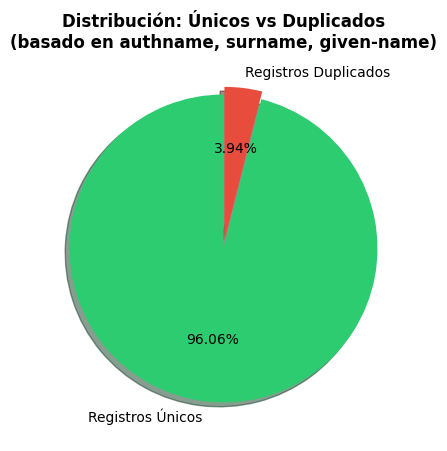

In [6]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

# Grafico: Pastel - Unicos vs Duplicados
ax1 = axes
labels_pie = ['Registros Únicos', 'Registros Duplicados']
sizes_pie = [autores_unicos, autores_duplicados]
colors_pie = ['#2ecc71', '#e74c3c']
explode_pie = (0, 0.05)

ax1.pie(sizes_pie, explode=explode_pie, labels=labels_pie, colors=colors_pie,
        autopct='%1.2f%%', shadow=True, startangle=90)
ax1.set_title('Distribución: Únicos vs Duplicados\n(basado en authname, surname, given-name)', 
              fontsize=12, fontweight='bold')

In [7]:
dups.to_csv("data/entities/autores_ec_duplicados.csv", index=False)

Se debe definir los criterios que se utilizaran para aplicar la desambiguacion, que por lo general se dan por variaciones en la escritura del nombre e incluso autores diferentes pueden tener mismo authname. 